# Retention and KPIs

Notebook 04 showed that late delivery is not the main reason customers fail to return.
This notebook describes the retention picture directly, segments customers by value, and
produces the summary tables used in the dashboard.

A customer counts as returning only if they placed another order more than one day after
their first purchase, the split-basket rule defined in notebook 02.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

orders = pd.read_csv('../data/order_level.csv')
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# Each customer's first purchase, and how far each order sits from it
first_purchase = orders.groupby('customer_unique_id')['order_purchase_timestamp'].min()
orders['first_purchase'] = orders['customer_unique_id'].map(first_purchase)
orders['days_since_first'] = (
    orders['order_purchase_timestamp'] - orders['first_purchase']
).dt.total_seconds() / 86400

# Cohort = month of first purchase. Offset = calendar months after that.
orders['cohort_month'] = orders['first_purchase'].dt.to_period('M')
orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
orders['month_offset'] = (
    (orders['order_month'].dt.year - orders['cohort_month'].dt.year) * 12
    + (orders['order_month'].dt.month - orders['cohort_month'].dt.month)
)

# CHECK: genuine returners should give the same 2.13% as notebook 02
returns = orders[orders['days_since_first'] > 1]
n_customers = orders['customer_unique_id'].nunique()
n_returners = returns['customer_unique_id'].nunique()
print("Customers:", n_customers)
print("Genuine returners:", n_returners, "(", round(n_returners / n_customers * 100, 2), "% )")
print()

# Size of each cohort
cohort_size = orders.groupby('cohort_month')['customer_unique_id'].nunique()

# Customers returning in each month after their first purchase
returning = returns.groupby(['cohort_month', 'month_offset'])['customer_unique_id'].nunique()
returning = returning.unstack()

# Convert counts to a share of each cohort
retention = returning.divide(cohort_size, axis=0) * 100

# Usable window only, and month 1 onward
retention = retention.loc['2017-01':]
retention = retention.drop(columns=0, errors='ignore')

print("Cohort sizes (first-time customers per month):")
print(cohort_size.loc['2017-01':])
print()
print("Average share returning 1 month after first purchase:",
      round(retention[1].mean(), 2), "%")

Customers: 93350
Genuine returners: 1993 ( 2.13 % )

Cohort sizes (first-time customers per month):
cohort_month
2017-01     717
2017-02    1628
2017-03    2503
2017-04    2256
2017-05    3450
2017-06    3037
2017-07    3752
2017-08    4057
2017-09    4004
2017-10    4328
2017-11    7059
2017-12    5338
2018-01    6842
2018-02    6288
2018-03    6774
2018-04    6582
2018-05    6506
2018-06    5875
2018-07    5946
2018-08    6144
Freq: M, Name: customer_unique_id, dtype: int64

Average share returning 1 month after first purchase: 0.48 %


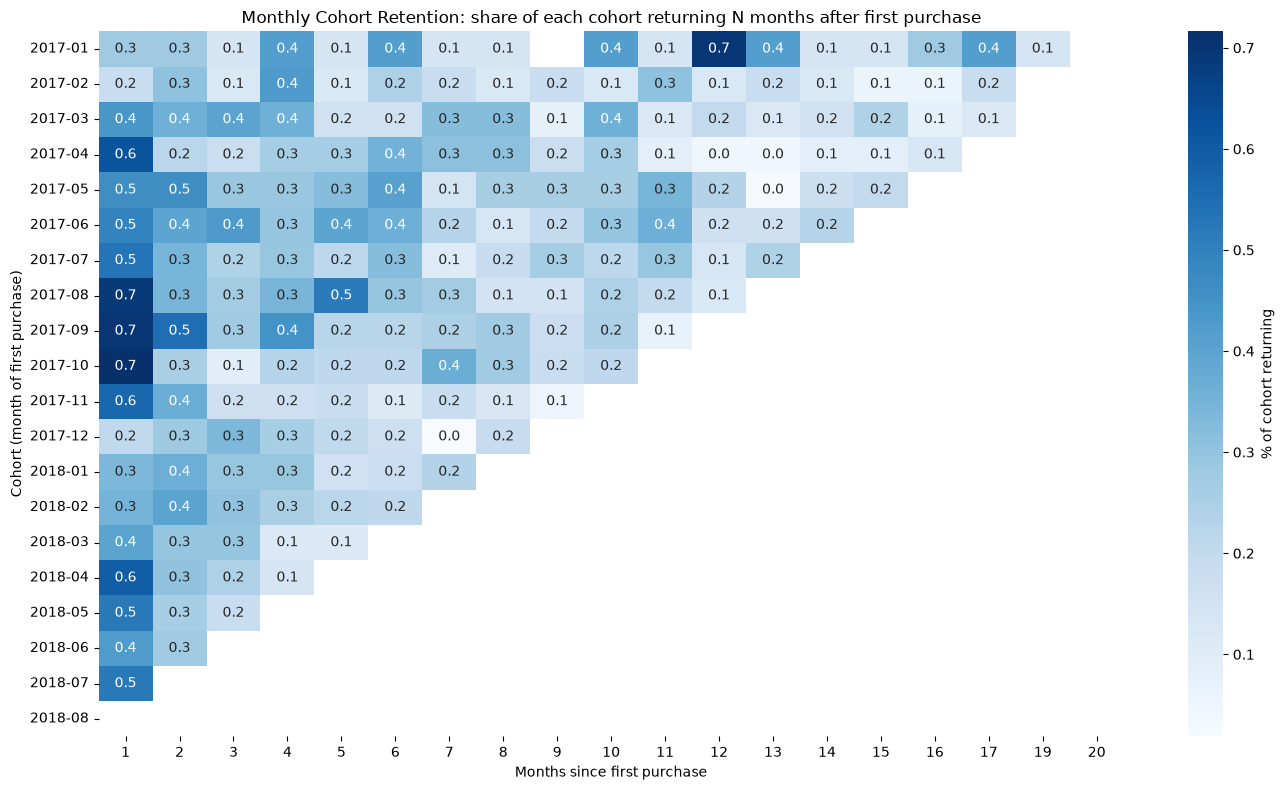

In [2]:
plt.figure(figsize=(14, 8))
sns.heatmap(retention, annot=True, fmt='.1f', cmap='Blues',
            cbar_kws={'label': '% of cohort returning'})
plt.title('Monthly Cohort Retention: share of each cohort returning N months after first purchase')
plt.xlabel('Months since first purchase')
plt.ylabel('Cohort (month of first purchase)')
plt.tight_layout()
plt.savefig('../outputs/cohort_retention.png', dpi=150)
plt.show()

### Result: there is no retention curve

A healthy cohort heatmap shows a strong first column fading gradually to the right. This one
is almost flat. An average of 0.48% of each cohort returns in month 1, and months 2 through
20 sit between roughly 0.1% and 0.4% with no clear decline.

**This is not a retention curve decaying, it is background noise.** A small and roughly
constant share of each cohort happens to buy again in any given month.

**Individual cells should not be over-read.** Most represent between 5 and 30 customers. The
darkest cell, the January 2017 cohort at month 12, is 0.7% of a 717-customer cohort, which
is five people.

**Retention did not improve as the platform grew.** Cohorts from late 2017 return at 0.6–0.7%
in month 1; cohorts from mid-2018 return at 0.4–0.6%, despite the customer base tripling.

**The business problem is not churn, it is that repeat purchase never begins.** Retention
work usually means slowing a drop-off. Here there is no drop-off, because almost no customer
makes a second purchase. This also explains why the delivery-to-retention effect in notebook
04 was so small: there is very little repeat behaviour for any factor to influence.

**Limitation.** `customer_unique_id` is Olist's own identifier for linking a person's orders.
If it fails to link some returning customers, genuine repeat purchases would appear as new
customers and the 2.13% rate would be understated. This cannot be verified within the dataset.

# Part 2: Where the value sits, and who returns

In [3]:
customers = pd.read_csv('../data/customer_level.csv')

print("Customers:", len(customers))
print("Repeat customers:", customers['is_repeat_customer'].sum())
print()

# How concentrated is revenue?
total_revenue = customers['monetary'].sum()
sorted_spend = customers['monetary'].sort_values(ascending=False)
for share in [0.01, 0.05, 0.10, 0.20]:
    n = int(len(customers) * share)
    pct = sorted_spend.head(n).sum() / total_revenue * 100
    print("Top", int(share * 100), "% of customers:", round(pct, 1), "% of revenue")
print()

# Monetary quartile: 4 = highest spenders
by_monetary = customers.groupby('monetary_quartile').agg(
    customers=('customer_unique_id', 'count'),
    total_revenue=('monetary', 'sum'),
    avg_spend=('monetary', 'mean'),
    repeat_rate_pct=('is_repeat_customer', 'mean')
)
by_monetary['revenue_share_pct'] = (by_monetary['total_revenue'] / total_revenue * 100).round(1)
by_monetary['repeat_rate_pct'] = (by_monetary['repeat_rate_pct'] * 100).round(2)
by_monetary['avg_spend'] = by_monetary['avg_spend'].round(2)

print("By monetary quartile (4 = highest spenders):")
print(by_monetary[['customers', 'avg_spend', 'revenue_share_pct', 'repeat_rate_pct']])
print()

# Recency quartile: 4 = most recent buyers
by_recency = customers.groupby('recency_quartile').agg(
    customers=('customer_unique_id', 'count'),
    avg_recency_days=('recency_days', 'mean'),
    repeat_rate_pct=('is_repeat_customer', 'mean')
)
by_recency['avg_recency_days'] = by_recency['avg_recency_days'].round(0)
by_recency['repeat_rate_pct'] = (by_recency['repeat_rate_pct'] * 100).round(2)

print("By recency quartile (4 = most recent):")
print(by_recency)

Customers: 93358
Repeat customers: 1993

Top 1 % of customers: 11.5 % of revenue
Top 5 % of customers: 29.1 % of revenue
Top 10 % of customers: 41.1 % of revenue
Top 20 % of customers: 56.6 % of revenue

By monetary quartile (4 = highest spenders):
                   customers  avg_spend  revenue_share_pct  repeat_rate_pct
monetary_quartile                                                          
1                      23340      29.10                5.1             0.27
2                      23340      65.43               11.6             0.99
3                      23339     117.74               20.8             1.87
4                      23339     354.23               62.5             5.42

By recency quartile (4 = most recent):
                  customers  avg_recency_days  repeat_rate_pct
recency_quartile                                              
1                     23340             501.0             1.25
2                     23340             326.0             2.02
3  

In [4]:
orders_all = pd.read_csv('../data/order_level.csv')
orders_all['order_purchase_timestamp'] = pd.to_datetime(orders_all['order_purchase_timestamp'])

# Each customer's first occasion (orders within a day of their first purchase)
first_ts = orders_all.groupby('customer_unique_id')['order_purchase_timestamp'].min()
orders_all['first_purchase'] = orders_all['customer_unique_id'].map(first_ts)
orders_all['days_since_first'] = (
    orders_all['order_purchase_timestamp'] - orders_all['first_purchase']
).dt.total_seconds() / 86400

first_occ = orders_all[orders_all['days_since_first'] <= 1]

# Summarise each customer's first occasion
first_summary = first_occ.groupby('customer_unique_id').agg(
    first_value=('order_value', 'sum'),
    first_items=('n_items', 'sum'),
    first_was_late=('is_late', 'max'),
    first_freight=('freight_value', 'sum'),
    state=('customer_state', 'first')
).reset_index()

# Attach whether they ever returned
first_summary = first_summary.merge(
    customers[['customer_unique_id', 'is_repeat_customer']],
    on='customer_unique_id', how='inner'
)

returners = first_summary[first_summary['is_repeat_customer'] == 1]
one_timers = first_summary[first_summary['is_repeat_customer'] == 0]

print("Returners:", len(returners), " One-time:", len(one_timers))
print()
print("                        Returners   One-time")
print("Median first order value  ", round(returners['first_value'].median(), 2), "    ",
      round(one_timers['first_value'].median(), 2))
print("Mean first order value    ", round(returners['first_value'].mean(), 2), "    ",
      round(one_timers['first_value'].mean(), 2))
print("Median items              ", returners['first_items'].median(), "       ",
      one_timers['first_items'].median())
print("Late first order (%)      ", round(returners['first_was_late'].mean() * 100, 1), "      ",
      round(one_timers['first_was_late'].mean() * 100, 1))
print("Median freight            ", round(returners['first_freight'].median(), 2), "     ",
      round(one_timers['first_freight'].median(), 2))
print()

# Return rate by state, largest markets only
by_state = first_summary.groupby('state').agg(
    customers=('customer_unique_id', 'count'),
    return_rate_pct=('is_repeat_customer', 'mean')
)
by_state['return_rate_pct'] = (by_state['return_rate_pct'] * 100).round(2)
by_state = by_state[by_state['customers'] >= 1000].sort_values('return_rate_pct', ascending=False)
print("Return rate by state (1,000+ customers):")
print(by_state)

Returners: 1993  One-time: 91357

                        Returners   One-time
Median first order value   89.0      88.0
Mean first order value     130.5      138.79
Median items               1.0         1.0
Late first order (%)       5.2        6.9
Median freight             16.79       17.32

Return rate by state (1,000+ customers):
       customers  return_rate_pct
state                            
RJ         11913             2.38
SP         39138             2.27
ES          1927             2.23
GO          1894             2.22
RS          5165             2.13
MG         10998             2.04
SC          3445             2.00
PR          4768             1.97
BA          3158             1.93
DF          2018             1.78
PE          1548             1.55
CE          1257             1.11
